# Ensemble (앙상블)
- 여러 머신러닝 모델을 결합해서 더 강력한 모델을 만드는 기법

## 대표적인 Ensemble 방법
- Voting(보팅)
    - 서로 다른 알고리즘을 결합해서 사용
    - 여러 모델의 예측결과를 투표를 통해 최종 결정
- Bagging(배깅, Bootstrap Aggregation)
    - 같은 알고리즘을 결합, 서로 다른 훈련 데이터로 학습
    - 샘플을 여러번 뽑아(Bootstrap) 각 모델을 학습시킨 결과를 집계(Aggregation)
- Boosting(부스팅)
    - 여러 모델이 순차적으로 학습
    - 이전 모델의 결과에 따라 다음 모델에 가중치 부여
- Stacking(스택킹, Stacked Generalization)
    - 여러 모델이 예측한 결과 값을 다른 모델의 학습 데이터로 입력하여 재학습

## Voting(보팅)
- Hard Vorting (직접 투표)
    - 각 모델의 예측 결과 중 많은 것을 선택
        - 1 예측 : 3표
        - 2 예측 : 1표

    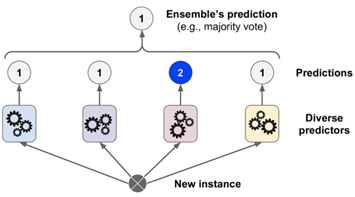

- Soft Voting (간접 투표)
    - 각 모델의 클래스 확률 평균
    - 평균 확률이 높은 것을 선택
        - 1 평균 확률 : (0.9 + 0.8 + 0.3 + 0.4)/4 = 0.6
        - 2 평균 확률 : (0.1 + 0.2 + 0.7 + 0.6)/4 = 0.4

    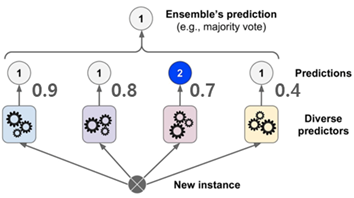
    
- 일반적으로 soft voting의 성능이 높음

- Voting 모델
    - ```sklearn.ensemble.VotingClassifier(estimators, voting, ..)```
        - `estimators` : voting에 참여할 모델들
        - `voting` : hard(기본값), soft
    - ```sklearn.ensemble.VotingRegressor(estimators, weights, ..)```
        - `estimators` : voting에 참여할 모델들
        - `weights` : 모델별 부여할 가중치 순서, None(기본값, 가중치 없음)

회귀의 경우 전체 결과의 평균이 기준이지만 weights를 통해 가중치를 부여할 수 있다.

####[예제] wine class 분류

In [ ]:
# 데이터 추출 및 분할
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

wine = load_wine()

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(wine.data,
                                                            wine.target,
                                                            stratify=wine.target,
                                                            test_size=0.3,
                                                            random_state=0)

In [ ]:
# Voting 참여할 분류모델 생성
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# KNN3/5, Logistic, DT3/5 (5개의 모델 생성)
knn3 = KNeighborsClassifier(n_neighbors=3)
knn5 = KNeighborsClassifier(n_neighbors=5)
log = LogisticRegression(max_iter=10000) # 반복설정
dt3 = DecisionTreeClassifier(max_depth=3, random_state=0)
dt5 = DecisionTreeClassifier(max_depth=5,random_state=0)

In [ ]:
# Voting 모델 생성
from sklearn.ensemble import VotingClassifier
# hard voting
hard = VotingClassifier(estimators=[('knn3', knn3),('knn5', knn5),('log', log),
                                     ('dt3', dt3),('dt5', dt5)],
                        voting='hard')
# soft voting
soft = VotingClassifier(estimators=[('knn3', knn3),('knn5', knn5),('log', log),
                                     ('dt3', dt3),('dt5', dt5)],
                        voting='soft')

In [ ]:
# 각 분류모델 성능평가
models = [('HardVoting',hard), ('SoftVoting',soft),
          ('KNN3', knn3),('KNN5', knn5),('LogisticReg', log),
          ('DecisionTree3', dt3),('DecisionTree55', dt5)]

for name, model in models:
    model.fit(X_train_w, y_train_w)
    print(name)
    print(f"Train Score: {model.score(X_train_w, y_train_w)}")
    print(f"Test Score: {model.score(X_test_w, y_test_w)}")

# 결과에서 voting 모두 다른 모델보다 높은 것을 확인할 수 있다.

HardVoting
Train Score: 1.0
Test Score: 0.9629629629629629
SoftVoting
Train Score: 1.0
Test Score: 0.9629629629629629
KNN3
Train Score: 0.8951612903225806
Test Score: 0.6481481481481481
KNN5
Train Score: 0.8145161290322581
Test Score: 0.7222222222222222
LogisticReg
Train Score: 0.9919354838709677
Test Score: 0.9629629629629629
DecisionTree3
Train Score: 0.9838709677419355
Test Score: 0.9629629629629629
DecisionTree55
Train Score: 1.0
Test Score: 0.9444444444444444


####[예제] 당뇨병 수치 예측

In [ ]:
# 데이터 추출 및 분할
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

diabetes = load_diabetes()
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(diabetes.data,
                                                            diabetes.target,
                                                            test_size=0.3,
                                                            random_state=0)

In [ ]:
# Voting 참여할 모델 생성
# Linear, Poly, Ridge, Lasso, DT
from sklearn.preprocessing import *
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline

poly = PolynomialFeatures(degree=2, include_bias=False)
scaler = MinMaxScaler()
reg = LinearRegression()
poly_reg = Pipeline([('poly', poly), ('reg', reg)])
ridge = Pipeline([('scaler', scaler),('ridge', Ridge(alpha=0.1))])
lasso = Pipeline([('scaler', scaler),('ridge', Lasso(alpha=0.1))])
dt = DecisionTreeRegressor(max_depth=3,random_state=0)

In [ ]:
# Voting 모델 생성
from sklearn.ensemble import VotingRegressor
voting = VotingRegressor(estimators=[('reg', reg),('poly',poly_reg),
                                     ('ridge', ridge), ('lasso', lasso),
                                     ('dt', dt)])

In [ ]:
# 각 모델 성능평가
models = [('Voting', voting),('LinearReg', reg),
          ('PolyReg',poly_reg),('Ridge', ridge),
          ('Lasso', lasso),('DecisionTree', dt)]

for name, model in models :
  model.fit(X_train_d, y_train_d)
  print(name)
  print('Train Score:', model.score(X_train_d, y_train_d))
  print('Test Score:', model.score(X_test_d, y_test_d))

# 밑의 결과자체도 높지 않기 때문에 voting한 결과도 높지 않은 것을 볼 수 있다.
# 이렇게 voting은 사용한 모델에 따라 결과값이 달라진다
# 각각 하나의 모델을 쓰는 것보다는 좋을 수 있다.

# ◆ voting은 회귀문제보다는 분류문제에 더 좋은 효과를 기대할 수 있다.

Voting
Train Score: 0.6181744689047466
Test Score: 0.37938999848614874
LinearReg
Train Score: 0.553937891544893
Test Score: 0.39289927216962905
PolyReg
Train Score: 0.6569756197470977
Test Score: 0.2253537278852088
Ridge
Train Score: 0.5535175311757001
Test Score: 0.39098414715740615
Lasso
Train Score: 0.552847743593892
Test Score: 0.3889039007196322
DecisionTree
Train Score: 0.5744216142994143
Test Score: 0.18816346294107056


## Bagging (배깅, Bootstrap Aggregation)
- 샘플을 여러번 뽑아 각 모델을 학습시켜 결과물을 집계
- 분류 모델에서는 Voting을 회귀모델에서는 평균으로 집계

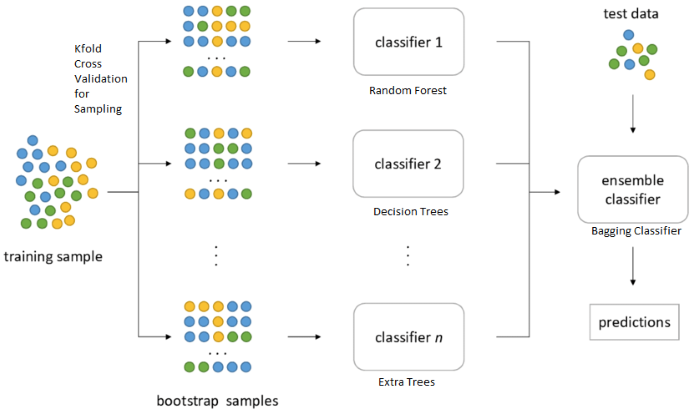

데이터를 두세개씩 나눠서 같은 알고리즘을 여러개 학습해 그거에 대한 결과를 집계<br>


### Random Forest
- 대표적인 Bagging 알고리즘
- 기본적으로 조금씩 다른 여러 Decision Tree의 묶음
- 각 Decision Tree는 비교적 예측을 잘하지만, 데이터의 일부에 과대적합하는 경향을 가진다는 점을 이용
- 서로 다른 데이터를 학습하여 과대적합된 트리를 많이 만들고 결과를 집계함으로써 과대적합이 상쇄되어 성능이 향상
```
sklearn.ensemble.RandomForestClassifier/RandomForestRegressor
```

#### Random Forest 동작과정
1. 생성할 트리 개수(`n_estimators`, 기본값 100)를 정하고 Decision Tree를 여러 개 생성
2. 부트스트랩 샘플 생성 : n개의 샘플을 무작위로 여러번 추출
3. 무작위로 노드 생성 : 각 Decision Tree의 노드는 최선의 특서이 아닌 랜덤하게 노드를 선택하여 생성
    - `max_features`로 선택할 무작위 특성의 개수 지정 가능(기본값 1)
4. 모델 훈련 : 중복되는 데이터로 각 Decision Tree 학습
5. 집계하여 예측 : 각 Decision Tree의 결과를 통해 집계하여 최종 예측값 선택

#### Random Forest 장단점
- 장점
    - 과대적합이 줄어듦
    - Decision Tree 모델의 예측 성능 유지
    - 매개변수의 튜닝을 많이 하지 않아도 좋은 성능을 보임
- 단점
    - Decision Tree를 많이 만들어야 함
    - 대량의 데이터라면 다소 시간이 오래 걸림
    - 텍스트 데이터와 같이 차원이 높고 희소한 데이터에는 잘 동작하지 않음



decisionTree 랜덤하게 100개 만들고 voting, regression의 경우 평균을 내는 방식.

####[예제] wine class 분류

In [ ]:
# Random Forest 모델
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(max_depth=5, random_state=0)
rf.fit(X_train_w, y_train_w)
print('Train score:', rf.score(X_train_w, y_train_w))
print('Test score:', rf.score(X_test_w, y_test_w))

# 둘다 1이 되었다.

Train score: 1.0
Test score: 1.0


####[예제] 당뇨병 수치 예측

In [ ]:
# Random Forest 모델
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor(ccp_alpha=100, random_state=0)
rfr.fit(X_train_d, y_train_d)

print('Train score:', rfr.score(X_train_d, y_train_d))
print('Test score:', rfr.score(X_test_d, y_test_d))

# ccp_alpha를 키우면 과대적합을 방지할 수 있다.
# test score가 올라간 것을 볼 수 있다.

Train score: 0.690482501101331
Test score: 0.3464153626549863


In [ ]:
# voting은 모델을 여러개 만들어줌
# bagging은 decisiontree 하나 샘플을 랜덤으로 여러개.. 다른 파라미터들에 대해 조정을 해줌으로 조절

In [ ]:
# voting은 tree가 아닌 다른 유형들을 가져가야할 때 사용
# regression 회귀모델 같은 경우에는 voting이 더 괜찮을 수 있다.
# voting시에 decision tree의 결과가 더 좋다면 radomforest를 사용.
# 분류모델같은 경우 tree가 정확도가 좋은 경우가 많기 때문에 bagging 모델(randomforest)를 사용한다.

## Boosting(부스팅)
- 여러 개의 약한 학습모델(weak learner)를 순차적으로 연결하여 이전 모델에서 발생한 오류에 대해 가중치를 부여하는 방법
- 주요 모델
    - Adaptive Boosting
        - 잘못 예측된 데이터에 가중치를 높여서 새로운 모델 학습
    - Gradient Boosting
        - 비용함수의 가중치로 오답 가중치를 부여

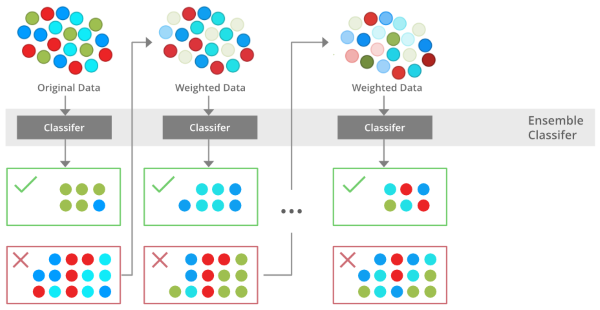

### Gradient Tree Boosting
- 여러개의 Decision Tree를 묶어 강력한 모델을 만드는 앙상블 기법
- 이전 트리의 오차를 보완하는 방식으로 순차적으로 트리를 생성
- 강력한 사전 가지치기를 사용하여, 1~5 Depth 정도의 깊지 않은 트리를 사용하므로 메모리를 적게 사용하고 예측이 빠름
- 얕은 트리 모델(weak learner)을 많이 연결하는 것
- 각각의 트리는 데이터 일부에 대해서만 예측을 잘 수행할 수 있어 트리가 많이 추가될수록 성능이 좋아짐
```
sklearn.ensemble.GradientBoostingClassifier/GradientBoostingRegressor
```
    - `n_estimators` : 부스팅 반복횟수, 생성할 트리의 개수(기본값 100)
    - `learning_rate` : 오차에 대한 보정 정도(기본값 0.1)

max_depth를 깊게 안가기 때문에 randomforest보다 빠르다.

####[예제] wine class 분류

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
# 모델 생성
gb = GradientBoostingClassifier(random_state=0, verbose=1) # max_depth 기본값 3 / verbose=1: 내가 학습한 순서들 별로 반복할 때마다 변화하는 값을 볼 수 있다.
# 모델 학습
gb.fit(X_train_w, y_train_w)
# 모델 평가
print("Train Score:", gb.score(X_train_w, y_train_w))
print("Test Score:", gb.score(X_test_w, y_test_w))

      Iter       Train Loss   Remaining Time 
         1           0.9028            0.78s
         2           0.7619            0.64s
         3           0.6495            0.59s
         4           0.5578            0.55s
         5           0.4819            0.53s
         6           0.4182            0.51s
         7           0.3631            0.49s
         8           0.3153            0.48s
         9           0.2740            0.47s
        10           0.2386            0.46s
        20           0.0617            0.41s
        30           0.0179            0.36s
        40           0.0051            0.31s
        50           0.0015            0.25s
        60           0.0005            0.20s
        70           0.0001            0.15s
        80           0.0000            0.10s
        90           0.0000            0.05s
       100           0.0000            0.00s
Train Score: 1.0
Test Score: 0.9814814814814815


In [ ]:
# 트리기반으로 모델을 재학습해서 반복하는 형태

####[예제] 당뇨병 수치 예측

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor(random_state=0, learning_rate=0.01, verbose=1)
gbr.fit(X_train_d, y_train_d)
print("Train score:", gbr.score(X_train_d, y_train_d))
print("Test score:", gbr.score(X_test_d, y_test_d))

# learning_rate
# Gradient Boosting 모델이 새로운 트리를 학습할 때, 이전 트리의 오차(잔차)를 얼마나 반영할지 조절하는 하이퍼파라미터
# 값이 크면 빠르게 학습하지만 불안정해지고, 작으면 학습이 느려지지만 더 정교해진다.

# 잔차제곱의 합을 가져오기 때문에 train loss 의 숫자가 크다.

      Iter       Train Loss   Remaining Time 
         1        6214.5817            0.25s
         2        6144.1515            0.24s
         3        6075.1138            0.23s
         4        6007.4250            0.23s
         5        5941.0744            0.22s
         6        5876.0199            0.22s
         7        5812.2373            0.21s
         8        5749.6678            0.21s
         9        5688.3215            0.20s
        10        5628.1410            0.20s
        20        5088.2730            0.18s
        30        4637.7000            0.15s
        40        4259.8432            0.13s
        50        3943.0401            0.11s
        60        3676.6801            0.08s
        70        3447.3634            0.06s
        80        3251.0469            0.06s
        90        3080.1499            0.04s
       100        2916.8991            0.00s
Train score: 0.5360015789484853
Test score: 0.3410797698026362


### XGBoost (Extreme Gradient Boost)
- GTB을 기반으로 하여 속도와 성능을 크게 개선한 알고리즘
    - 병렬 처리를 통해 학습하여 속도 개선
    - 가중치 규제(L1, L2)를 지원하여 과적합 방지
- 정형데이터를 가지고 예측할 때 매우 우수한 성능을 보임
- https://xgboost.readthedocs.io/en/stable/index.html
```
xgboost.XGBClassifier/XGBRegressor
```
    - `objective` : 학습 목적 및 방법(기본값 'reg:squarederror')
        - "reg:linear" : linear regression
        - "reg:logistic" : logistic regression
        - "binary:logistic" : binary classification
        - "multi:softmax" : multiclass classification
    - `booster` : 부스팅에 사용할 모델(기본값 gbtree)
        - gbtree, gblinear, dart
    - `n_estimators` : 부스팅반복횟수(기본값 100)
    - `eta`, `learning_rate` : 오차에 대한 보정 정도(기본값 0.1)
    - `alpha` , `reg_alpha` : L1규제에 대한 규제강도(기본값 0)
    - `lambda`, `reg_lambda` : L2규제에 대한 규제강도(기본값 0)

In [ ]:
# gradientboosting은 순차적 XGBoost는 병렬적으로 한번에
# 둘다 트리모델 기반으로 과적합 가능성이 있음
# XGBoost는
# 모델은 gbtree, gblinear, dart 중에 선택해서 쓸수 있고
# dart 모델은 의미없는 것을 삭제하는 형태
# XGBoost같은 경우 가중치 규제를 지원해 과적합을 방지한다.

#gradientboosting은 트리기반이라 분류에 적합하고
# XGBoost는 objective 하이퍼파라미터를 통해 선택해줄 수 있기 때문에 gradientboosting보다는 낫다.
# 그래도 결국 트리기반이기 때문에 분류에 적합하다고도 볼 수 있다.

####[예제] wine class 분류

In [ ]:
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state=0, objective = 'multi:softmax')
xgb.fit(X_train_w, y_train_w)

print("Train Score:", xgb.score(X_train_w, y_train_w))
print("Test Score:", xgb.score(X_test_w, y_test_w))

# 위의 gb와 동일한 결과

Train Score: 1.0
Test Score: 0.9814814814814815


####[예제] 당뇨병 수치 예측

In [ ]:
from xgboost import XGBRegressor
xgbr = XGBRegressor(random_state=0, learning_rate=0.01)
xgbr.fit(X_train_d, y_train_d)
print("Train score:", xgbr.score(X_train_d, y_train_d))
print("Test score:", xgbr.score(X_test_d, y_test_d))

Train score: 0.7529878760648389
Test score: 0.3206749992764263


In [ ]:
xgbr = XGBRegressor(random_state=0, learning_rate=0.01, reg_lambda=0.1)
xgbr.fit(X_train_d, y_train_d)
print("Train score:", xgbr.score(X_train_d, y_train_d))
print("Test score:", xgbr.score(X_test_d, y_test_d))

In [ ]:
# booster를 gblinear로 변경
xgblr = XGBRegressor(random_state=0, learning_rate=0.01, booster = 'gblinear')
xgblr.fit(X_train_d, y_train_d)
print("Train score:", xgblr.score(X_train_d, y_train_d))
print("Test score:", xgblr.score(X_test_d, y_test_d))

# gb모델에서 동일하게 했던 것보다 향상된 것을 볼 수 있다.

Train score: 0.5195162351163373
Test score: 0.40589028742501265


### LightGBM (Light Gradient Boosting Machine)
- Microsoft에서 개발한 XGBoost의 변형 알고리즘
- 메모리 사용량이 적고 속도가 빠르므로, 대규모 데이터셋에 매우 효과적
- Gradient-based One Side Sampling (GOSS)기법을 사용하여 빠르게 학습 가능
    - Gradient를 기반으로 중요한 샘플을 선택적으로 사용
    - 큰 Gradient를 가진 샘플(예측을 잘못한 샘플)들을 모두 사용
    - 작은 Gradient를 가진 샘플들은 일부 랜덤 선택
- Tree를 수직적으로 확장하여 메모리 효율성 향상
    - 한 번에 하나의 특성에 대해서만 분할을 고려
    - GBT와 XGBoost는 모든 특성에 대해 가능한 분할을 시도하여 수평적으로 Tree를 확장
- https://lightgbm.readthedocs.io/en/stable/index.html
```
lightgbm
```
- 데이터셋 지정 : `Dataset()`함수를 통해 Dataset객체로 변환 필요
- 학습 : `train(params, train_set, valid_sets)`
    - `params` : 하이퍼파라미터에에 대한 값을 딕셔러니 타입으로 지정
    - `train_set` : 학습 데이터 지정
    - `valid_sets` : 검증 데이터 지정(검증데이터셋이 없다면 평가데이터 지정)
- 예측 : `predict()`
- 성능평가 : `score()`함수가 지원되지 않아 예측된 결과를 기반으로 `sklearn.metric`을 이용하여 평가

####[예제] wine class 분류

In [ ]:
import lightgbm as lgb
from sklearn.metrics import r2_score

# Dataset형식으로 데이터 변환
train_data_w = lgb.Dataset(X_train_w, y_train_w)
test_data_w = lgb.Dataset(X_test_w, y_test_w, reference=train_data_w) # reference -> 나중에 검증 위해서

# 파라미터 지정
params = {'objective' : 'multiclass', 'num_class' : 3, 'verbosity':-1}

# 모델 학습
lgbm = lgb.train(params, train_set=train_data_w, valid_sets=test_data_w)

# 결과 예측
train_pred = lgbm.predict(X_train_w).argmax(axis=1) #argmax 해줘서 1차원 데이터가 나온다.
test_pred = lgbm.predict(X_test_w).argmax(axis=1)

# 성능평가
train_pred.shape, test_pred.shape
print("Train Score:" , r2_score(y_train_w, train_pred))
print("Test Score:", r2_score(y_test_w, test_pred))

# boost로만 봤을 때는 train에 비해 testscore가 낮았는데
# 이 모델은 둘다 1.0으로 잘 분리된 것을 볼 수 있다.

# 모델들이 발전한 이유는 속도와 성능의 차이이다 파라미터를 다양하게 하며 성능을 더 높일 수 있다.

Train Score: 1.0
Test Score: 1.0


####[예제] 당뇨병 수치 예측

In [ ]:
import lightgbm
from sklearn.metrics import r2_score

# dataset 형식으로 데이터 변환
train_data_d = lgb.Dataset(X_train_d, y_train_d)
test_data_d = lgb.Dataset(X_test_d, y_test_d, reference=train_data_d)

# 파라미터 설정
params = {'objective' : 'regression'}

# 모델학습
lgbm = lgb.train(params, train_set=train_data_d, valid_sets=test_data_d)

# 예측
train_pred = lgbm.predict(X_train_d)
test_pred = lgbm.predict(X_test_d)

# 성능평가
print('Train Score:' , r2_score(y_train_d, train_pred))
print('Test Score:', r2_score(y_test_d, test_pred))

Train Score: 0.9184470800799801
Test Score: 0.25757690807345535


In [ ]:
# 일반 boosting 보다는 XGBoost를 많이 쓰고 대규모일 때는 LightGBM을 쓴다.

## Stacking(스택킹)
- 여러 모델이 예측한 결과값을 다른 모델의 학습 데이터로 입력하여 재학습
- 기반모델(Base Model)과 메타모델(Meta Model)로 구분 가능
    - 기반모델(Base Model) : 학습에 참여할 모델
    - 메타모델(Meta Model) : 최종 예측을 수행할 학습모델

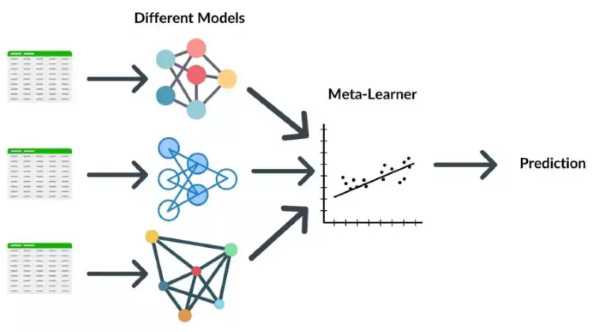

```
sklearn.ensemble.StackingClassifier/StackingRegressor
```

- `estimators` : 학습에 참여할 모델(base model)
- `final_estimator` : 최종 예측을 수행할 학습 모델(meta model)
    - Classifier의 기본값은 LogisticRegression
    - Regressor의 기본값은 RidgeCV

In [ ]:
# 여러 모델들의 결과를 기반으로 다시 한 모델로 학습
# boosting과 bagging은 tree모델을 기반으로하는데
# voting과 stacking은 내가 정의한 모델들을 사용할 수 있다.

# 그리고 다른 모델들은 집계를 사용하는 반면, 모든 결과를 가지고 다시 최종예측을 수행한다.

####[예제] wine class 분류

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import *
from sklearn.tree import DecisionTreeClassifier
# 기본모델은 DT, RF, GB
estimators = [('dt', DecisionTreeClassifier(random_state=0)), # 분류니까 max_depth없이
              ('rf', RandomForestClassifier(random_state=0)),
              ('gb', GradientBoostingClassifier(random_state=0))]

# 스택킹
stack = StackingClassifier(estimators=estimators)
stack.fit(X_train_w, y_train_w)

print("Train score:", stack.score(X_train_w, y_train_w))
print("Test score:", stack.score(X_test_w, y_test_w))

Train score: 1.0
Test score: 1.0


####[예제] 당뇨병 수치 예측

In [ ]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import *
# 기본모델은 linear, RF, GB
estimators = [('reg', LinearRegression()),
              ('rf', RandomForestRegressor(random_state=0)),
              ('gb', GradientBoostingRegressor(random_state=0))]
stackr= StackingRegressor(estimators=estimators)
stackr.fit(X_train_d, y_train_d)
print("Train score:", stackr.score(X_train_d, y_train_d))
print("Test score:", stackr.score(X_test_d, y_test_d))

# 값은 낮지만 stacking이 voting이나 randomforest 보다 좋은 결과

Train score: 0.6712323648106894
Test score: 0.39251291988369763


#[실습]
1. 유방암 진단에 대한 앙상블 모델 실습
2. [보스턴주택가격예측](https://drive.google.com/file/d/17ygxKFk3IyOhe6lIWm1OBqUY6eeDq3I8/view?usp=drive_link)에 대한 앙상블 모델 실습

In [ ]:
# 둘다 XGB 가제일 낫다??

### 유방암 진단

In [ ]:
# 1. 유방암 진단에 대한 앙상블 모델 실습 (분류모델)
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()

from sklearn.model_selection import train_test_split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(cancer.data,
                                                    cancer.target,
                                                    stratify=cancer.target,
                                                    test_size=0.3,
                                                    random_state=0)

#### Voting 모델

In [ ]:
# Voting 참여할 분류모델 생성
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# KNN3/5, Logistic, DT3/5
knn3 = KNeighborsClassifier(n_neighbors=3)
knn5 = KNeighborsClassifier(n_neighbors=5)
log = LogisticRegression(max_iter=10000)
dt3 = DecisionTreeClassifier(max_depth=3, random_state=0)
dt5 = DecisionTreeClassifier(max_depth=5, random_state=0)

In [ ]:
# Voting 모델 생성
from sklearn.ensemble import VotingClassifier
# hard voting
hard = VotingClassifier(estimators=[('knn3', knn3), ('knn5', knn5), ('log', log),
                                    ('dt3', dt3), ('dt5', dt5)],
                        voting='hard')
# soft voting
soft = VotingClassifier(estimators=[('knn3', knn3), ('knn5', knn5), ('log', log),
                                    ('dt3', dt3), ('dt5', dt5)],
                        voting='soft')

In [ ]:
# 각 분류모델 성능평가
models = [('HardVoting', hard), ('SoftVoting', soft),
            ('KNN3', knn3), ('KNN5', knn5), ('LogisticReg', log),
            ('DecisionTree3', dt3), ('DecisionTree5', dt5)]

for name, model in models:
    model.fit(X_train_c, y_train_c)
    print(name)
    print(f"Train Score: {model.score(X_train_c, y_train_c)}")
    print(f"Test Score: {model.score(X_test_c, y_test_c)}")

HardVoting
Train Score: 0.9849246231155779
Test Score: 0.9239766081871345
SoftVoting
Train Score: 0.992462311557789
Test Score: 0.9298245614035088
KNN3
Train Score: 0.9597989949748744
Test Score: 0.9181286549707602
KNN5
Train Score: 0.9447236180904522
Test Score: 0.9122807017543859
LogisticReg
Train Score: 0.9723618090452262
Test Score: 0.9298245614035088
DecisionTree3
Train Score: 0.9798994974874372
Test Score: 0.9005847953216374
DecisionTree5
Train Score: 0.9974874371859297
Test Score: 0.9122807017543859


#### Bagging 모델(Random Forest 모델)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(max_depth=5, random_state=0)
rf.fit(X_train_c, y_train_c)
print("Train Score:", rf.score(X_train_c, y_train_c))
print("Test SCore:", rf.score(X_test_c, y_test_c))

Train Score: 0.9974874371859297
Test SCore: 0.9473684210526315


#### Boosting(부스팅)

##### Gradient Tree Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=0)
gb.fit(X_train_c, y_train_c)
print("Train Score:", gb.score(X_train_c, y_train_c))
print("Test Score:", gb.score(X_test_c, y_test_c))

Train Score: 1.0
Test Score: 0.9415204678362573


##### XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=0, objective='binary:logistic')
xgb.fit(X_train_c, y_train_c)
print("Train score:", xgb.score(X_train_c, y_train_c))
print("Test score:", xgb.score(X_test_c, y_test_c))

Train score: 1.0
Test score: 0.9473684210526315


##### LightGBM

In [ ]:
import lightgbm as lgb
from sklearn.metrics import r2_score

train_data_c = lgb.Dataset(X_train_c, y_train_c)
test_data_c = lgb.Dataset(X_test_c, y_test_c, reference = train_data_c)

params = {'objective' : 'binary', 'verbosity' : -1}

lgbm = lgb.train(params, train_set=train_data_c, valid_sets=test_data_c)

train_pred = lgbm.predict(X_train_c)
test_pred = lgbm.predict(X_test_c)

print("Train score:", r2_score(y_train_c, train_pred))
print("Test score:", r2_score(y_test_c, test_pred))

Train score: 0.9999958391515273
Test score: 0.8033735170022962


#### Stacking

In [ ]:
from sklearn.ensemble import *
from sklearn.tree import DecisionTreeClassifier
# 기본모델은 DT, RF, GB
estimators = [('dt', DecisionTreeClassifier(random_state=0)),
              ('rf', RandomForestClassifier(random_state=0)),
              ('gb', GradientBoostingClassifier(random_state=0))]

# 스택킹
stack = StackingClassifier(estimators=estimators)
stack.fit(X_train_c, y_train_c)

print("Train score:", stack.score(X_train_c, y_train_c))
print("Test score:", stack.score(X_test_c, y_test_c))

Train score: 1.0
Test score: 0.9415204678362573


### 보스턴주책가격예측

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 2. 보스턴주택가격예측에 대한 앙상블 모델 실습
import pandas as pd

boston = pd.read_csv('/content/drive/MyDrive/boston.csv')
X_data = boston.drop(columns='MEDV')
y_data = boston['MEDV']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_data,
                                                             y_data,
                                                             test_size=0.3,
                                                             random_state=0)

#### Voting 모델

In [ ]:
# Voting 참여할 모델 생성
# Linear, Poly, Ridge, Lasso, DT
from sklearn.preprocessing import *
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline

poly = PolynomialFeatures(degree=2, include_bias=False)
scaler = MinMaxScaler()
reg = LinearRegression()
poly_reg = Pipeline([('poly', poly), ('reg', reg)])
ridge = Pipeline([('scaler', scaler), ('ridge', Ridge(alpha=0.1))])
lasso = Pipeline([('scaler', scaler), ('lasso', Lasso(alpha=0.1))])
dt = DecisionTreeRegressor(max_depth=3, random_state=0)

In [ ]:
# Voting 모델 생성
from sklearn.ensemble import VotingRegressor
voting = VotingRegressor(estimators=[('reg', reg), ('poly', poly_reg),
                                     ('ridge', ridge), ('lasso', lasso),
                                     ('dt', dt)])

In [ ]:
# 각 모델 성능평가
models = [('Voting', voting), ('LinearReg', reg),
            ('PolyReg', poly_reg), ('Ridge', ridge), ('Lasso', lasso),
            ('DecisionTree', dt)]
for name, model in models:
    model.fit(X_train_b, y_train_b)
    print(name)
    print("Train Score:", model.score(X_train_b, y_train_b))
    print("Test Score:", model.score(X_test_b, y_test_b))

Voting
Train Score: 0.8780567130157099
Test Score: 0.7989216073193195
LinearReg
Train Score: 0.7645451026942549
Test Score: 0.6733825506400162
PolyReg
Train Score: 0.9517246762476055
Test Score: 0.6486839499941324
Ridge
Train Score: 0.764465990615874
Test Score: 0.6728277207399964
Lasso
Train Score: 0.7191346660701974
Test Score: 0.612339328896518
DecisionTree
Train Score: 0.8511285677547421
Test Score: 0.6628873063238391


#### Bagging 모델 (Random Forest 모델)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor(random_state=0)
rfr.fit(X_train_b, y_train_b)
print("Train Score:", rfr.score(X_train_b, y_train_b))
print("Test Score:", rfr.score(X_test_b, y_test_b))

Train Score: 0.9839083903792409
Test Score: 0.8258927744705352


#### Boosting(부스팅)

##### Gradient Tree Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor(random_state=0)
gb.fit(X_train_b, y_train_b)
print("Train Score:", gb.score(X_train_b, y_train_b))
print("Test Score:", gb.score(X_test_b, y_test_b))

Train Score: 0.985130906801384
Test Score: 0.8395589233926679


##### XGBoost

In [ ]:
from xgboost import XGBRegressor
xgbr = XGBRegressor(random_state=0)
xgbr.fit(X_train_b, y_train_b)
print("Train score:", xgbr.score(X_train_b, y_train_b))
print("Test score:", xgbr.score(X_test_b, y_test_b))

Train score: 0.9999989493423611
Test score: 0.8499410478426069


##### LightGBM

In [ ]:
import lightgbm as lgb
from sklearn.metrics import r2_score

# dataset 형식으로 데이터 변환
train_data_b = lgb.Dataset(X_train_b, y_train_b)
test_data_b = lgb.Dataset(X_test_b, y_test_b)

params = {'objective': 'regression'}

lgbm = lgb.train(params,train_set=train_data_b, valid_sets=test_data_b)

train_pred = lgbm.predict(X_train_b)
test_pred = lgbm.predict(X_test_b)

print("train score:", r2_score(y_train_b, train_pred))
print("test score:", r2_score(y_test_b, test_pred))


train score: 0.9749167404410678
test score: 0.7776907433136433


#### Stacking

In [ ]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import *
# 기본모델은 linear, RF, GB
estimators = [('reg', LinearRegression()),
              ('rf', RandomForestRegressor(random_state=0)),
              ('gb', GradientBoostingRegressor(random_state=0))]
stackr= StackingRegressor(estimators=estimators, final_estimator=LinearRegression())
stackr.fit(X_train_b, y_train_b)
print("Train score:", stackr.score(X_train_b, y_train_b))
print("Test score:", stackr.score(X_test_b, y_test_b))

Train score: 0.9769158796462157
Test score: 0.8334275405692501


### 강사님 풀이

In [ ]:
# 데이터 추출 및 분할
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(cancer.data,
                                                            cancer.target,
                                                            stratify=cancer.target,
                                                            test_size=0.3,
                                                            random_state=0)

In [ ]:
# 필요한 패키지 import
from sklearn.neighbors import *
from sklearn.linear_model import *
from sklearn.tree import *
from sklearn.ensemble import *
from xgboost import *
from sklearn.preprocessing import *
from sklearn.pipeline import Pipeline
import lightgbm as lgb

In [ ]:
# 학습 모델 정의
estimators = [
    ('KNN5', KNeighborsClassifier(n_neighbors=5)),
    ('LogisticRegression', LogisticRegression()),
    ('DecisionTree5', DecisionTreeClassifier(max_depth=5, random_state=0)),
    ('RandomForest', RandomForestClassifier(random_state=0)),
    ('GradientBoosting', GradientBoostingClassifier(random_state=0)),
    ('XGBoost', XGBClassifier(random_state=0))
]

models = [
    ('KNN5', KNeighborsClassifier(n_neighbors=5)),
    ('LogisticRegression', LogisticRegression()),
    ('DecisionTree5', DecisionTreeClassifier(max_depth=5, random_state=0)),
    ('HardVoting', VotingClassifier(estimators=estimators, voting='hard')),
    ('SoftVoting', VotingClassifier(estimators=estimators, voting='soft')),
    ('RandomForest', RandomForestClassifier(random_state=0)),
    ('GradientBoosting', GradientBoostingClassifier(random_state=0)),
    ('XGBoost', XGBClassifier(random_state=0)),
    ('Staking', StackingClassifier(estimators=estimators))
]

In [ ]:
# 모델 학습 및 결과 저장
import pandas as pd
cancer_scores = pd.DataFrame(columns=['Model', 'Train Score', 'Test Score'])
for name, model in models:
    model.fit(X_train_c, y_train_c)
    train_score = model.score(X_train_c, y_train_c)
    test_score = model.score(X_test_c, y_test_c)
    cancer_scores.loc[len(cancer_scores)] = [name, train_score, test_score]

In [ ]:
from sklearn.metrics import r2_score

train_data = lgb.Dataset(X_train_c, y_train_c)
test_data = lgb.Dataset(X_test_c, y_test_c, reference=train_data)

params = {'objective' : 'binary', 'early_stopping_rounds' : 5, 'verbosity':-1}

# 오류
# 'objective' : 'binary' 이것만 쓰면
# [LightGBM] Warning] No further splits with positive gain, best gain: -inf
# warning이 뜬다.
# 내가 유의미하게 만들 수 있는 트리가 없다.
# 이미 디폴트가 100번인데 2-30번 돌고 값이 더이상 안올라감
# 해결방법
# 'verbosity':-1 을 추가해서 warning을 무시하거나
# 'early_stopping_rounds' : 5 -> 다섯번동안 개선되지 않으면 그냥 중간에 종료해
lgbm = lgb.train(params, train_data, valid_sets=test_data)
train_pred = lgbm.predict(X_train_c)
test_pred = lgbm.predict(X_test_c)

train_score = r2_score(y_train_c, train_pred)
test_score = r2_score(y_test_c, test_pred)
cancer_scores.loc[len(cancer_scores)] = ['LightGBM', train_score, test_score]

In [ ]:
cancer_scores.sort_values(by='Test Score', ascending=False)

,Model,Train Score,Test Score
8,Staking,0.997487,0.964912
5,RandomForest,1.000000,0.953216
4,SoftVoting,1.000000,0.947368
7,XGBoost,1.000000,0.947368
3,HardVoting,1.000000,0.941520
6,GradientBoosting,1.000000,0.941520
1,LogisticRegression,0.962312,0.935673
0,KNN5,0.944724,0.912281
2,DecisionTree5,0.997487,0.912281
9,LightGBM,0.994617,0.798861


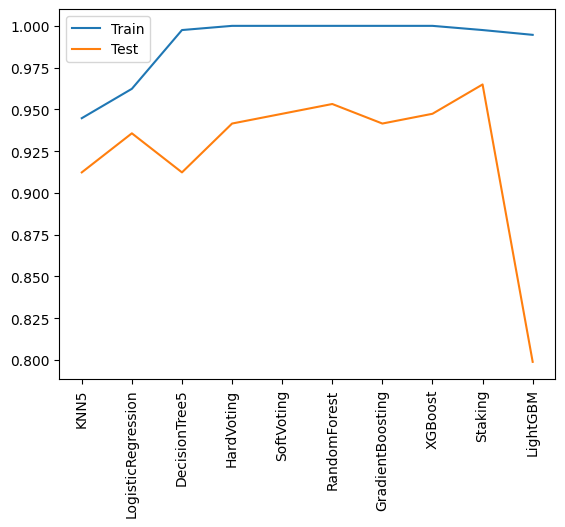

In [ ]:
import matplotlib.pyplot as plt
plt.plot(cancer_scores['Model'], cancer_scores['Train Score'], label='Train')
plt.plot(cancer_scores['Model'], cancer_scores['Test Score'], label='Test')
plt.xticks(rotation=90)
plt.legend()

- stacking 의 결과가 가장 좋음

In [ ]:
# 데이터 추출 및 분할
boston = pd.read_csv('/content/boston.csv')
X_data = boston.drop('MEDV', axis=1)
y_data = boston['MEDV']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_data,
                                                            y_data,
                                                            test_size=0.3,
                                                            random_state=0)

In [ ]:
# 학습 모델 정의

estimators = [
    ('LinearRegeression', LinearRegression()),
    ('PolyRegression', Pipeline([('poly', PolynomialFeatures(degree=2)),
                                 ('linear', LinearRegression())])),
    ('Ridge', Pipeline([('scaler', MinMaxScaler()),
                        ('poly', PolynomialFeatures(degree=3)),
                        ('ridge', Ridge(alpha=0.1))])),
    ('Lasso', Pipeline([('scaler', MinMaxScaler()),
                        ('poly', PolynomialFeatures(degree=3)),
                        ('lasso', Lasso(alpha=0.1))])),
    ('DecisionTree5', DecisionTreeRegressor(max_depth=5, random_state=0)),
    ('RandomForest', RandomForestRegressor(random_state=0)),
    ('GradientBoosting', GradientBoostingRegressor(random_state=0)),
    ('XGBoost', XGBRegressor(random_state=0))
]

models =[
    ('LinearRegeression', LinearRegression()),
    ('PolyRegression', Pipeline([('poly', PolynomialFeatures(degree=2)),
                                 ('linear', LinearRegression())])),
    ('Ridge', Pipeline([('scaler', MinMaxScaler()),
                        ('poly', PolynomialFeatures(degree=3)),
                        ('ridge', Ridge(alpha=0.1))])),
    ('Lasso', Pipeline([('scaler', MinMaxScaler()),
                        ('poly', PolynomialFeatures(degree=3)),
                        ('lasso', Lasso(alpha=0.1))])),
    ('Voting', VotingRegressor(estimators=estimators)),
    ('RandomForest', RandomForestRegressor(random_state=0)),
    ('GradientBoosting', GradientBoostingRegressor(random_state=0)),
    ('XGBoost', XGBRegressor(random_state=0)),
    ('Stacking', StackingRegressor(estimators=estimators))
]

In [ ]:
# 모델 학습 및 결과 저장
import pandas as pd
boston_scores = pd.DataFrame(columns=['Model', 'Train Score', 'Test Score'])
for name, model in models:
    model.fit(X_train_b, y_train_b)
    train_score = model.score(X_train_b, y_train_b)
    test_score = model.score(X_test_b, y_test_b)
    boston_scores.loc[len(boston_scores)] = [name, train_score, test_score]

In [ ]:
train_data = lgb.Dataset(X_train_b, y_train_b)
test_data = lgb.Dataset(X_test_b, y_test_b, reference=train_data)
params = {'objective' : 'regression', 'verbosity' : -1}
lgbm = lgb.train(params, train_set=train_data, valid_sets=test_data)
train_pred = lgbm.predict(X_train_b)
test_pred = lgbm.predict(X_test_b)
boston_scores.loc[len(boston_scores)] = ['LightGBM',
                                         r2_score(y_train_b, train_pred),
                                         r2_score(y_test_b, test_pred)]

In [ ]:
boston_scores.sort_values(by='Test Score', ascending=False)

,Model,Train Score,Test Score
7,XGBoost,0.999999,0.849941
4,Voting,0.963206,0.845355
6,GradientBoosting,0.985131,0.839559
8,Stacking,0.976798,0.828323
5,RandomForest,0.983908,0.825893
2,Ridge,0.953244,0.819528
9,LightGBM,0.974917,0.777691
3,Lasso,0.776448,0.691201
0,LinearRegeression,0.764545,0.673383
1,PolyRegression,0.951725,0.648684


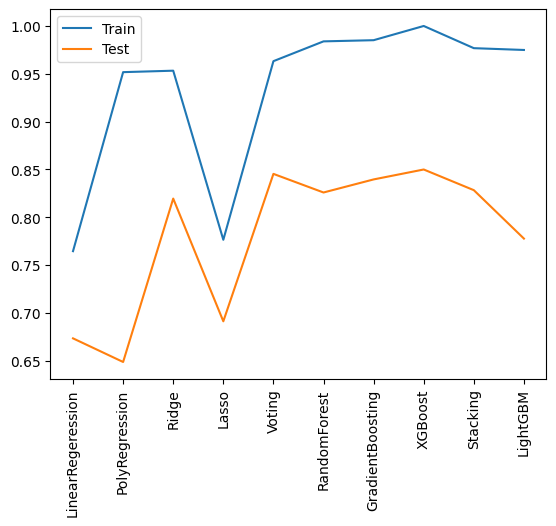

In [ ]:
plt.plot(boston_scores['Model'], boston_scores['Train Score'], label='Train')
plt.plot(boston_scores['Model'], boston_scores['Test Score'], label='Test')
plt.xticks(rotation=90)
plt.legend()

- XGBoost가 좋음